In [1]:
!unzip archive\ \(3\).zip

Archive:  archive (3).zip
  inflating: train.csv               


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('train.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [8]:
df = df.sort_values('Order Date')

In [11]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales = monthly_sales.to_timestamp()

monthly_sales.head()

,Sales
Order Date,
2015-01-01,14205.707
2015-02-01,4519.892
2015-03-01,55205.797
2015-04-01,27906.855
2015-05-01,23644.303


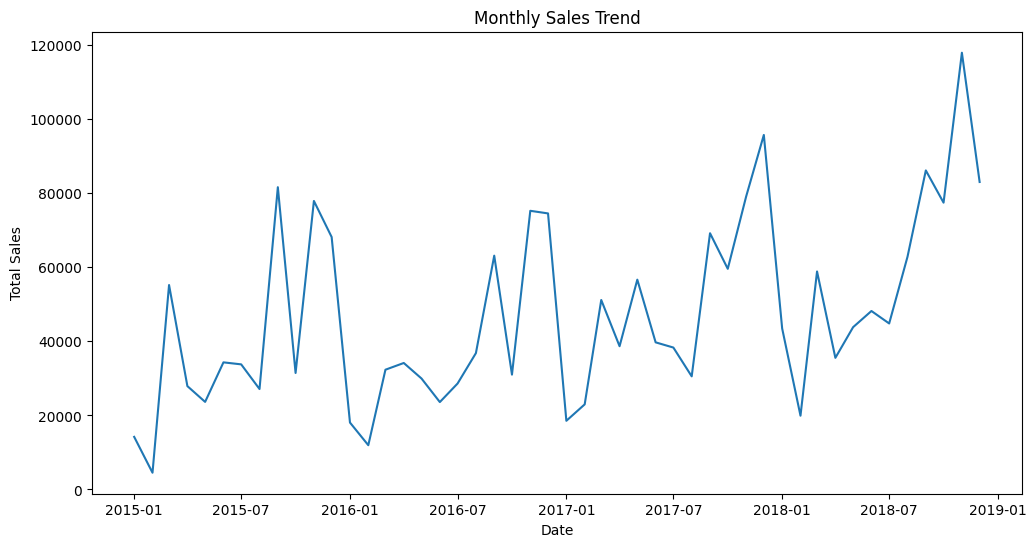

In [12]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

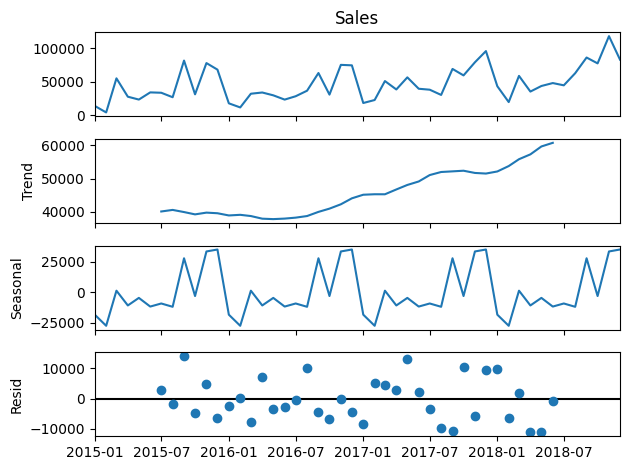

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales, model='additive')

decomposition.plot()

plt.show()

In [15]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_sales, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -539.293
Date:                Wed, 11 Mar 2026   AIC                           1084.585
Time:                        07:14:43   BIC                           1090.136
Sample:                    01-01-2015   HQIC                          1086.674
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2546      0.265      0.961      0.337      -0.265       0.774
ma.L1         -0.8477      0.144     -5.898      0.000      -1.129      -0.566
sigma2      5.791e+08   8.52e-11   6.79e+18      0.0

In [16]:
forecast = model_fit.forecast(steps=12)

forecast

,predicted_mean
2019-01-01,74121.351923
2019-02-01,71852.991900
2019-03-01,71275.437079
2019-04-01,71128.383892
2019-05-01,71090.942182
2019-06-01,71081.409022
2019-07-01,71078.981752
2019-08-01,71078.363736
2019-09-01,71078.206381
2019-10-01,71078.166317


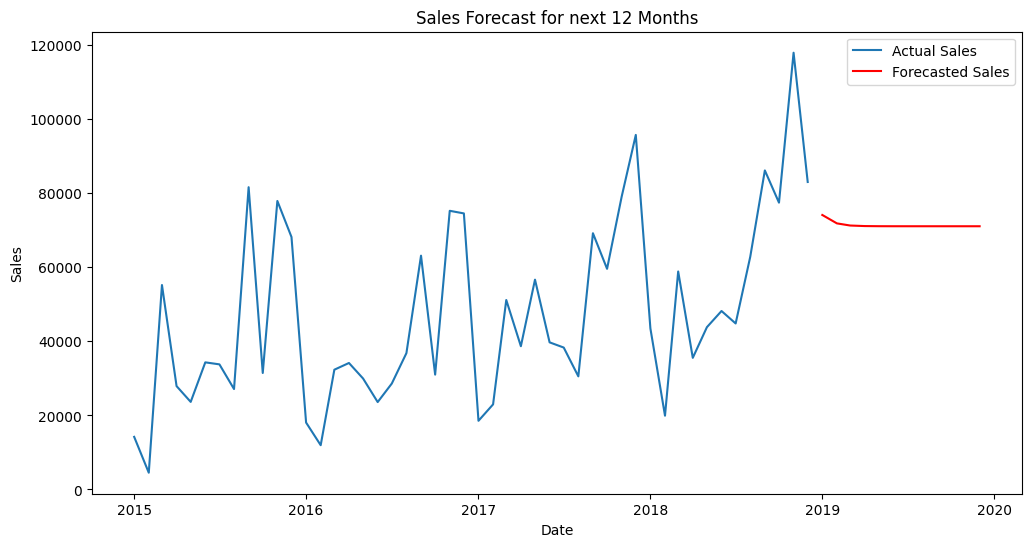

In [20]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales, label='Actual Sales')
plt.plot(forecast, label='Forecasted Sales', color='red')

plt.title("Sales Forecast for next 12 Months")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

**Final Insights**

Sales Forecasting Insights

1.Monthly sales show a clear upward trend over time, indicating business growth.

2.Seasonal decomposition revealed repeating sales spikes starting mid-year and declining after January.

3.A time-series forecasting model (ARIMA) was applied to predict future sales.

4.The forecast suggests stable future sales levels, though more advanced seasonal models could improve accuracy.

5.Forecasting helps businesses plan inventory, staffing, and marketing strategies.